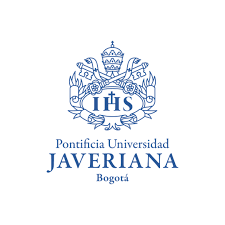
***Pontificia Universidad Javeriana***
# **Procesamiento de Alto Volumen de Datos**

### Taller: **Tratamiento de Datos y Machine Learning con PySpark**

Autor: Nicolas Puyana

Fecha de Inicio: 13 de Abril del 2026

Fecha actual: 25 de Abril del 2026

## **Problemática**

Se tiene que el tratamiento del agua debe ser indispensable para garantizar la pureza y la calidad. Uno de los elementos significativos es aplicar los conceptos de los Procesamientos de Datos en Alto Volúmen para solucionar este tipo de problemas que afectan la salud publica. El presente ejemplo tiene como propósito tener en cuenta una metodogología para aplicar el PAVD para solucionar o diagnósticar la calidad del agua en la INDIA.

## **Objetivo**

Implementar modelos de predicción utilizando la biblioteca de aprendizaje automático MLlib PySpark, con el fin de explorar y aplicar técnicas de IA en entornos de procesamiento con alto volúmen de datos.


## **Metodología**

1.- Importación de los datos (datos en diferentes formatos)

2.- Preprocesamiento y limpieza de valores nulos, cambio de datos, EDA, medidas estadísticas.

3.- Entrenamiento de modelos: RL (MLlib), tensores (KERAS); la idea es predecir la calidad del agua en la INDIA.

4.- Evaluación de los modelos: medidas de rendimiento tales como: precisión (precision), exactitud (accuracy), recall, F1 Score,entre otras.

5.- Se tiene como referencia de la calidad de los parámetros del agua, la referencia: https://www.intechopen.com/chapters/69568

## **1.- Importación de bibliotecas**

In [2]:
import os
import sys
sys.path.append('/usr/lib/python3/dist-packages/')  ##genera errores por geopandas
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pylab import *
import findspark
findspark.init()
import pyspark.sql.functions as F
from pyspark import SparkConf, SparkContext
from pyspark.sql import SQLContext
from pyspark.sql import SparkSession
from pyspark.sql.types import *

# Levantamiento de variables de entorno pip
import os

import sys

sys.path.append('/usr/lib/python3/dist-packages/')

import numpy as np

import pandas as pd

import seaborn as sns

import matplotlib.pyplot as plt

from pylab import *

import findspark

findspark.init()

import pyspark.sql.functions as F

from pyspark import SparkConf, SparkContext

from pyspark.sql import SQLContext

from pyspark.sql import SparkSession

from pyspark.sql.types import *

In [3]:
##Codigo para no tener problemas con la version de python 
##import os
##import sys


##os.environ['PYSPARK_PYTHON'] = 'python3'
##os.environ['PYSPARK_DRIVER_PYTHON'] = 'python3'
##print("Configuración de ruta completada.")

In [4]:
configura = SparkConf()

configura.setAppName("Calidad_Agua_Puyana")

sparkS = SparkSession.builder.config(conf=configura).getOrCreate()

SQLContext(sparkContext=sparkS.sparkContext, sparkSession=sparkS)

sparkPuyana = sparkS.sparkContext.getOrCreate()

print("Sesion creada: ProcesamientoDatos04")

sparkPuyana

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/26 11:12:21 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Sesion creada: ProcesamientoDatos04


<SparkContext master=spark://10.43.97.177:7077 appName=Calidad_Agua_Puyana>

### Levantamiento de sesión SPARK
configura = SparkConf()

configura.setAppName("Calidad_Agua_Corredor")

sparkS = SparkSession.builder.config(conf=configura).getOrCreate()

SQLContext(sparkContext=sparkS.sparkContext, sparkSession=sparkS)

sparkContextoS = sparkS.sparkContext.getOrCreate()

print("Sesion creada: ProcesamientoDatos04")

sparkCorredor

In [5]:
##No tenemos hadoop toca leerlo desde almacen 
df00=sparkS.read.format("csv").option("header","true").load("file:///Almacen/waterquality.csv")
df00.show(10)


[Stage 1:>                                                          (0 + 1) / 1]

+------------+--------------------+-----------+----+---+---+------------+----+-------------------+--------------+--------------+
|STATION CODE|           LOCATIONS|      STATE|TEMP| DO| pH|CONDUCTIVITY| BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|TOTAL_COLIFORM|
+------------+--------------------+-----------+----+---+---+------------+----+-------------------+--------------+--------------+
|        1312|GODAVARI AT JAYAK...|MAHARASHTRA|29.2|6.4|8.1|         735| 3.4|                  2|             3|            73|
|        2177|GODAVARI RIVER NE...|MAHARASHTRA|24.5|  6|  8|         270| 3.1|                  2|            72|           182|
|        2182|GODAVARI RIVER AT...|MAHARASHTRA|25.8|5.5|7.8|         355| 4.2|                  9|            59|           133|
|        2179|GODAVARI RIVER AT...|MAHARASHTRA|24.8|5.5|7.8|         371| 5.6|               3.55|            90|           283|
|        2183|GODAVARI RIVER AT...|MAHARASHTRA|25.7|5.7|7.9|         294| 3.2|               2.69

##**2.- Carga de Datos desde el HADOOP HDFS**

!/mnt/sda1/Cluster/Hadoop/bin/hadoop fs -ls /csv

df00 = sparkS.read.format("csv").option("header", "true").load("hdfs://10.195.34.34:9000/csv/waterquality.csv")

df00.show(5)

## **3.- Análisis y Preparación de Datos**

Se presentan datos (csv) con los diferentes parámetros de los rios de la India. Cada parámetro es el promedio de los valores medidos en un período de tiempo. Los datos han sido extraidos de la web oficial de la India (RiverIndia)

- Tipos de datos: coherencia de tipo de datos, transformación
- Columnas: conocimiento de las columnas, eliminación.
- Análisis de datos nulos o imposibles: concimiento.

In [6]:
##Conocimiento de las columnas
df00.columns

['STATION CODE',
 'LOCATIONS',
 'STATE',
 'TEMP',
 'DO',
 'pH',
 'CONDUCTIVITY',
 'BOD',
 'NITRATE_N_NITRITE_N',
 'FECAL_COLIFORM',
 'TOTAL_COLIFORM']

- STATION CODE: Código de estación de medida
- LOCATIONS: ubicaciones de los rios
- STATE: Estado de la india
- TEMP: Temperatura del agua en °C
- DO: Oxigeno Disuelto (mg/L). Concentraciones altas de oxigeno representa mejor calidad del agua.
- pH: Logaritmo negativo de la concentración de hidrógeno. Número adimensional para indicar la acidez del agua.
- CONDUCTIVITY: Mide la habilidad de una solución conducir corriente. El agua pura NO es conductora de corriente.
- BOD: Bacterias y otros microorganismos que utilizan sustancias orgánicas como alimento: Demanda Bioquímica de Oxigeno. Mayor cantidad de material orgánico mayor BOD.
- NITRATE_N_NITRITE_N: Nitratos/Nitritos "nitrógeno". Altas concentraciones Nitrogeno en la superficie del agua puede estimular el rápido crecimiento de algas las cuales degradan la calidad del agua (mg/L).
- FECAL_COLIFORM: Promedio de bacterias coliformes: excresiones.
- TOTAL_COLIFORM']: Se eliminará pues no aporta al estudio de predicción de la calidad del agua.

In [7]:
for valor in df00.columns:
    df00.describe([valor]).show()

+-------+-----------------+
|summary|     STATION CODE|
+-------+-----------------+
|  count|              534|
|   mean|2052.516853932584|
| stddev|755.2178560086894|
|    min|             1023|
|    max|               41|
+-------+-----------------+



+-------+-------------------+
|summary|          LOCATIONS|
+-------+-------------------+
|  count|                534|
|   mean|               NULL|
| stddev|               NULL|
|    min|          AHMEDABAD|
|    max|ZUARI AT PANCHAWADI|
+-------+-------------------+



+-------+--------------+
|summary|         STATE|
+-------+--------------+
|  count|           534|
|   mean|          NULL|
| stddev|          NULL|
|    min|ANDHRA PRADESH|
|    max|   WEST BENGAL|
+-------+--------------+



+-------+------------------+
|summary|              TEMP|
+-------+------------------+
|  count|               534|
|   mean|25.241398865784515|
| stddev|3.4480130875026624|
|    min|              10.5|
|    max|                NA|
+-------+------------------+

+-------+-----------------+
|summary|               DO|
+-------+-----------------+
|  count|              534|
|   mean|6.389812030075193|
| stddev|1.622861728733986|
|    min|                0|
|    max|               NA|
+-------+-----------------+

+-------+------------------+
|summary|                pH|
+-------+------------------+
|  count|               534|
|   mean|  7.79812734082397|
| stddev|0.6499503911518124|
|    min|              13.2|
|    max|               9.1|
+-------+------------------+

+-------+------------------+
|summary|      CONDUCTIVITY|
+-------+------------------+
|  count|               534|
|   mean| 684.9761904761905|
| stddev|1769.3297602834873|
|    min|               100|
|    max|           

+-------+-----------------+
|summary|              BOD|
+-------+-----------------+
|  count|              534|
|   mean|5.339772727272726|
| stddev|8.500503922190218|
|    min|              0.2|
|    max|               NA|
+-------+-----------------+

+-------+-------------------+
|summary|NITRATE_N_NITRITE_N|
+-------+-------------------+
|  count|                534|
|   mean| 1.3785714285714301|
| stddev|  2.803947753154703|
|    min|                  0|
|    max|                 NA|
+-------+-------------------+

+-------+-----------------+
|summary|   FECAL_COLIFORM|
+-------+-----------------+
|  count|              534|
|   mean|7384.170353982301|
| stddev|30714.05963523712|
|    min|                0|
|    max|               NA|
+-------+-----------------+

+-------+------------------+
|summary|    TOTAL_COLIFORM|
+-------+------------------+
|  count|               534|
|   mean|124396.96767676767|
| stddev|1458407.8189939584|
|    min|                 1|
|    max|           

**Se presenta las estadísticas de los datos a continuación:**

for valor in df00.columns:
  
  df00.describe([valor]).show()

## **Visualización de los DATOS NULOS**

#Cantidad de Valores Nulos o Imposibles

df00.select([F.count(F.when(F.isnan(c) | F.col(c).isNull(), c)).alias(c) for c in df00.columns]).show()

In [8]:
df00.select([F.count(F.when(F.isnan(c)|F.col(c).isNull(),c)).alias(c) for c in df00.columns]).show()

+------------+---------+-----+----+---+---+------------+---+-------------------+--------------+--------------+
|STATION CODE|LOCATIONS|STATE|TEMP| DO| pH|CONDUCTIVITY|BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|TOTAL_COLIFORM|
+------------+---------+-----+----+---+---+------------+---+-------------------+--------------+--------------+
|           0|        0|    0|   0|  0|  0|           0|  0|                  0|             0|             0|
+------------+---------+-----+----+---+---+------------+---+-------------------+--------------+--------------+





* Se observa que no hay datos nulos o imposibles
* Se procede a Graficar cada una de las dimensiones
* #Se crea una vista para ser usada en las visualizaciones
* df00.createOrReplaceTempView("df00_sql")
* df01 = sparkS.sql('''Select * from df00_sql where TEMP is not null and
  
             DO is not null and
  
             pH is not null and
  
             CONDUCTIVITY is not null and
  
             BOD is not null and
  
             NITRATE_N_NITRITE_N is not null and
  
             FECAL_COLIFORM is not null''')

In [9]:
##No hay datos nulos

#Se grafican las diferentes dimensiones 

#Se crea una vista para ser usada en las visualizaciones

df00.createOrReplaceTempView("df00_sql")
df01=sparkS.sql('''Select * from df00_sql where TEMP is not null and DO is not null and pH is not null and CONDUCTIVITY is not null and BOD is not null and NITRATE_N_NITRITE_N is not null and FECAL_COLIFORM is not null''')

* #Se verifica la Cantidad de Valores Nulos o Imposibles
* df01.select([F.count(F.when(F.isnan(c) | F.col(c).isNull(), c)).alias(c) for c in df01.columns]).show()

In [10]:
#Se verifica valores nulos en el temp que se reemplazo

df01.select([F.count(F.when(F.isnan(c) | F.col(c).isNull(), c)).alias(c) for c in df01.columns]).show()

[Stage 38:>                                                         (0 + 1) / 1]

+------------+---------+-----+----+---+---+------------+---+-------------------+--------------+--------------+
|STATION CODE|LOCATIONS|STATE|TEMP| DO| pH|CONDUCTIVITY|BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|TOTAL_COLIFORM|
+------------+---------+-----+----+---+---+------------+---+-------------------+--------------+--------------+
|           0|        0|    0|   0|  0|  0|           0|  0|                  0|             0|             0|
+------------+---------+-----+----+---+---+------------+---+-------------------+--------------+--------------+



### **Tratamiento de datos**

* df00.dtypes
* ##Se procede a cambiar los tipos de datos
* df00 = df00.withColumn('TEMP', df00['TEMP'].cast(FloatType()))
* df00 = df00.withColumn('pH', df00['pH'].cast(FloatType()))
* df00 = df00.withColumn('DO', df00['DO'].cast(FloatType()))
* df00 = df00.withColumn('CONDUCTIVITY', df00['CONDUCTIVITY'].cast(FloatType()))
* df00 = df00.withColumn('NITRATE_N_NITRITE_N', df00['NITRATE_N_NITRITE_N'].cast(FloatType()))
* df00 = df00.withColumn('FECAL_COLIFORM', df00['FECAL_COLIFORM'].cast(FloatType()))
* df00 = df00.withColumn('BOD', df00['BOD'].cast(FloatType()))
* df00.dtypes


* ##Se elimina la columna TOTAL_COLIFORM
* df01 = df00.drop('TOTAL_COLIFORM')
* df01.columns

In [11]:
df00.dtypes

[('STATION CODE', 'string'),
 ('LOCATIONS', 'string'),
 ('STATE', 'string'),
 ('TEMP', 'string'),
 ('DO', 'string'),
 ('pH', 'string'),
 ('CONDUCTIVITY', 'string'),
 ('BOD', 'string'),
 ('NITRATE_N_NITRITE_N', 'string'),
 ('FECAL_COLIFORM', 'string'),
 ('TOTAL_COLIFORM', 'string')]

In [12]:
#Cambiar los tipos de datos 
df00=df00.withColumn('TEMP',df00['TEMP'].cast(FloatType()))
df00=df00.withColumn('pH',df00['pH'].cast(FloatType()))
df00=df00.withColumn('DO',df00['DO'].cast(FloatType()))
df00=df00.withColumn('CONDUCTIVITY',df00['CONDUCTIVITY'].cast(FloatType()))
df00=df00.withColumn('BOD',df00['BOD'].cast(FloatType()))
df00=df00.withColumn('NITRATE_N_NITRITE_N',df00['NITRATE_N_NITRITE_N'].cast(FloatType()))
df00=df00.withColumn('FECAL_COLIFORM',df00['FECAL_COLIFORM'].cast(FloatType()))


In [13]:
df00.dtypes
#Es necesario eliminar 'TOTAL_COLIFORM'
df01=df00.drop('TOTAL_COLIFORM')
df01.columns
df01.dtypes
#La columna solo se borra en la copia que se le hace al template, en el df00 si sigue estando TOTAL_COLIFORM

[('STATION CODE', 'string'),
 ('LOCATIONS', 'string'),
 ('STATE', 'string'),
 ('TEMP', 'float'),
 ('DO', 'float'),
 ('pH', 'float'),
 ('CONDUCTIVITY', 'float'),
 ('BOD', 'float'),
 ('NITRATE_N_NITRITE_N', 'float'),
 ('FECAL_COLIFORM', 'float')]

In [14]:
#Creación de funcion LAMBDA que va a ayudar a realizar la limpieza tratamiento de los datos

df01.createOrReplaceTempView("df01_sql")

do_parametro = sparkS.sql("Select DO from df01_sql")
##Se genera una consulta para crear un vector a cada tabla dependiendo del parametro 
do_vector = do_parametro.rdd.map(lambda fila: fila.DO).collect()

##toca hacerlo para todas las variables 
ph_parametro= sparkS.sql("Select pH from df01_sql")
ph_vector=ph_parametro.rdd.map(lambda fila:fila.pH).collect()

cond_parametro=sparkS.sql("Select CONDUCTIVITY from df01_sql")
cond_vector=cond_parametro.rdd.map(lambda fila:fila.CONDUCTIVITY).collect()

bo_parametro=sparkS.sql("Select BOD from df01_sql")
bo_vector=bo_parametro.rdd.map(lambda fila:fila.BOD).collect()

nit_parametro=sparkS.sql("Select NITRATE_N_NITRITE_N from df01_sql")
nit_vector=nit_parametro.rdd.map(lambda fila:fila.NITRATE_N_NITRITE_N).collect()

fec_parametro=sparkS.sql("Select FECAL_COLIFORM from df01_sql")
fec_vector=fec_parametro.rdd.map(lambda fila:fila.FECAL_COLIFORM).collect()

26/04/26 11:13:04 WARN TaskSetManager: Lost task 0.0 in stage 41.0 (TID 28) (10.43.101.23 executor 0): java.io.IOException: Cannot run program "/usr/bin/python": error=2, No such file or directory
	at java.lang.ProcessBuilder.start(ProcessBuilder.java:1048)
	at org.apache.spark.api.python.PythonWorkerFactory.startDaemon(PythonWorkerFactory.scala:239)
	at org.apache.spark.api.python.PythonWorkerFactory.createThroughDaemon(PythonWorkerFactory.scala:139)
	at org.apache.spark.api.python.PythonWorkerFactory.create(PythonWorkerFactory.scala:107)
	at org.apache.spark.SparkEnv.createPythonWorker(SparkEnv.scala:124)
	at org.apache.spark.api.python.BasePythonRunner.compute(PythonRunner.scala:174)
	at org.apache.spark.api.python.PythonRDD.compute(PythonRDD.scala:67)
	at org.apache.spark.rdd.RDD.computeOrReadCheckpoint(RDD.scala:367)
	at org.apache.spark.rdd.RDD.iterator(RDD.scala:331)
	at org.apache.spark.scheduler.ResultTask.runTask(ResultTask.scala:93)
	at org.apache.spark.TaskContext.runTaskWi

* ###Grafica Los parámetros para conocer sus características: DO y PH

* tam = len(do_parametro)
* fig, ax1 = plt.subplots(num=None, figsize=(13,7), facecolor='w', edgecolor='k')
* ax1.plot(range(0,tam), do_parametro, label='Oxigeno Disuelto')
* ax1.plot(range(0,tam), ph_parametro, label='pH')
* fig.suptitle('Parámetro DO y pH de la calidad del Agua')
* legend=ax1.legend()
* plt.grid()
* plt.show()

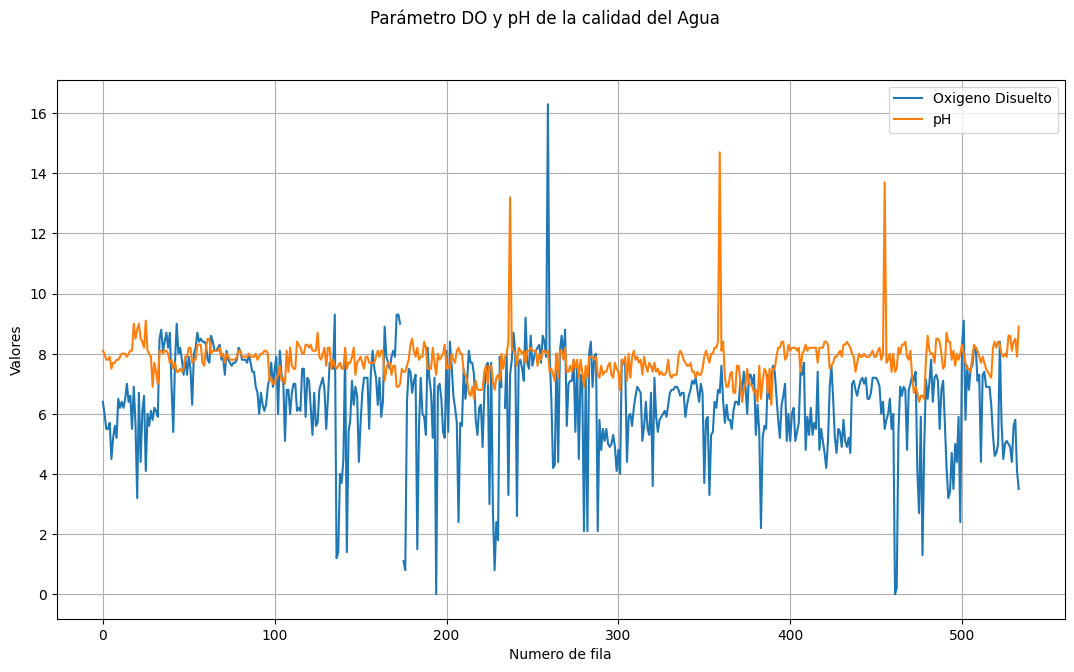

In [15]:
##GRAFICAR PARAMETROS PARA CONOCER SUS CARACTERISTICAS:DO Y PH 
tam=len(do_vector)
fig,ax1=plt.subplots(num=None,figsize=(13,7),facecolor='w',edgecolor='k')
ax1.plot(range(0,tam),do_vector,label='Oxigeno Disuelto')
ax1.plot(range(0,tam), ph_vector, label='pH')
fig.suptitle('Parámetro DO y pH de la calidad del Agua')
legend=ax1.legend()
plt.xlabel("Numero de fila")
plt.ylabel("Valores")
plt.grid()
plt.show()

* ###Grafica Los parámetros para conocer sus características: BOD y Nitrogrenos

* tam = len(do_parametro)
* fig, ax1 = plt.subplots(num=None, figsize=(13,7), facecolor='w', edgecolor='k')
* ax1.plot(range(0,tam), BOD_parametro, label='Oxigeno Disuelto')
* ax1.plot(range(0,tam), NN_parametro, label='NITRATE_N_NITRITE_N')
* fig.suptitle('Parámetro BOD y Nitrogenos de la calidad del Agua')
* legend=ax1.legend()
* plt.grid()
* plt.show()

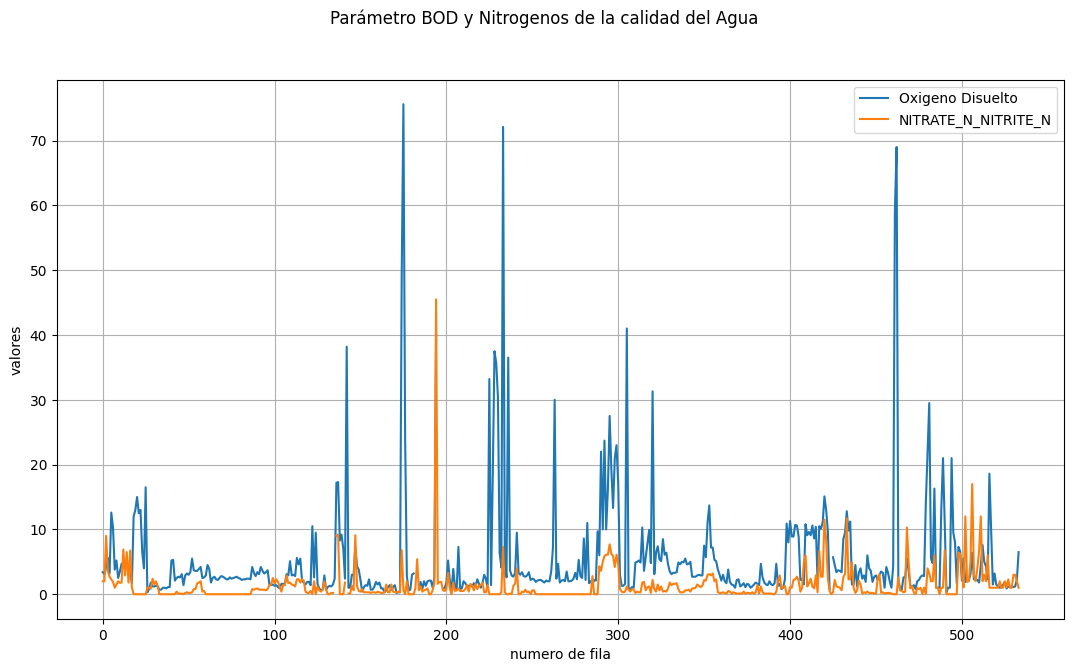

In [16]:
##Se hace el mismo proceso pero con BOD y Nitrogenos
tam:len(do_vector)
fig, ax1 = plt.subplots(num=None, figsize=(13,7), facecolor='w', edgecolor='k')
ax1.plot(range(0,tam), bo_vector, label='Oxigeno Disuelto')
ax1.plot(range(0,tam), nit_vector, label='NITRATE_N_NITRITE_N')
fig.suptitle('Parámetro BOD y Nitrogenos de la calidad del Agua')
legend=ax1.legend()
plt.xlabel("numero de fila")
plt.ylabel("valores")
plt.grid()
plt.show()

* ###Grafica Los parámetros para conocer sus características: FC y Conductividad

* tam = len(do_parametro)
* fig, ax1 = plt.subplots(num=None, figsize=(13,7), facecolor='w', edgecolor='k')
* ax1.plot(range(0,tam), COND_parametro, label='Conductividad')
* ax1.plot(range(0,tam), FC_parametro, label='FC_parametro')
* fig.suptitle('Parámetro Conductividad y Material Fecal de la calidad del Agua')
* legend=ax1.legend()
* plt.xlabel("Hola que tal estas")
* plt.grid()
* plt.show()

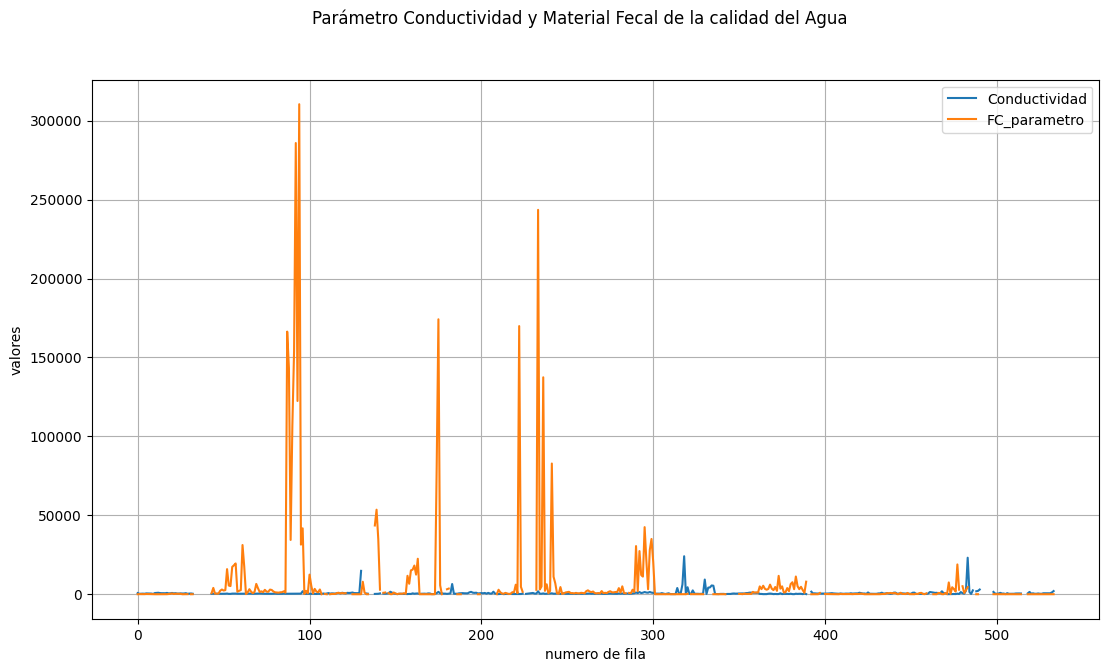

In [17]:
##Ahora con FC y CONDUCTIVITY

tam=len(do_vector)
fig, ax1 = plt.subplots(num=None, figsize=(13,7), facecolor='w', edgecolor='k')
ax1.plot(range(0,tam), cond_vector, label='Conductividad')
ax1.plot(range(0,tam), fec_vector, label='FC_parametro')
fig.suptitle('Parámetro Conductividad y Material Fecal de la calidad del Agua')
legend=ax1.legend()

plt.xlabel("numero de fila")
plt.ylabel("valores")
plt.grid()
plt.show()

* #Función definida por el usuario para definir el rango de calidad de agua según el pH
* #Se crea la columna para los rangos del parámetro (Según https://www.intechopen.com/chapters/69568)

* df02 = df01.withColumn("qrPH", F.when((df01.pH>=7) & (df01.pH<=8.5),100).

       when(((df01.pH>=6.8) & (df01.pH<6.9)) | ((df01.pH>8.5) & (df01.pH<8.6)), 80).

       when(((df01.pH>=6.7) & (df01.pH<6.8)) | ((df01.pH>=8.6) & (df01.pH<8.8)), 60).

       when(((df01.pH>=6.5) & (df01.pH<6.7)) | ((df01.pH>=8.8) & (df01.pH<9.0)), 40).otherwise(0))

In [18]:
##Funcion definida para los rangos de calidad de agua en base al pH

##se crea la columna para los rangos respectivos segun el link de apoyo sugerido 
df02=df01.withColumn("qrPH",F.when((df01.pH>=7)&(df01.pH<=8.5),100).
    when(((df01.pH>=6.8) & (df01.pH<6.9)) | ((df01.pH>8.5) & (df01.pH<8.6)), 80).
    when(((df01.pH>=6.7) & (df01.pH<6.8)) | ((df01.pH>=8.6) & (df01.pH<8.8)), 60).

    when(((df01.pH>=6.5) & (df01.pH<6.7)) | ((df01.pH>=8.8) & (df01.pH<9.0)), 40).otherwise(0))

* ### Función definida por el usuario para definir el rando de la calidad del agua según DO
* df02 = df02.withColumn("qrDO", F.when((df01.DO>=6.0), 100).
  *                    when((df01.DO>=5.1) & (df01.DO<6.0), 80).
  *                    when((df01.DO>=4.1) & (df01.DO<5.0), 60).
  *                    when((df01.DO>=3.0) & (df01.DO<=4.0), 40).otherwise(0))

In [19]:
##Funcion definida para los rangos de calidad del agua en base a DO

##Se crea la columna para los rangos respectivos segun el link de apoyo sugerido 
df02=df02.withColumn("qrDO",F.when((df01.DO>=6.0),100).
    when((df01.DO>=5.1) & (df01.DO<6.0), 80).
    when((df01.DO>=4.1) & (df01.DO<5.0), 60).
    when((df01.DO>=3.0) & (df01.DO<=4.0), 40).otherwise(0))
                     

* ### Función definida por el usuario para definir el rando de la calidad del agua según COND
* df02 = df02.withColumn("qrCOND", F.when(((df01.CONDUCTIVITY>=0.0) & (df01.CONDUCTIVITY<=75.0)), 100).
  *          when((df01.CONDUCTIVITY>75.0) & (df01.CONDUCTIVITY<=150.0), 80).
  *          when((df01.CONDUCTIVITY>150.0) & (df01.CONDUCTIVITY<=225.0), 60).
  *          when((df01.CONDUCTIVITY>225.0) & (df01.CONDUCTIVITY<=300.0), 40).otherwise(0))

In [20]:
##Funcion definida para los rangos de calidad del agua segun COND

##Se crea la columna para los rangos respectivos segun el link de apoyo sugerido 
df02=df02.withColumn("qrCOND",F.when(((df01.CONDUCTIVITY>=0.0)&(df01.CONDUCTIVITY<=75.0)),100).
     when((df01.CONDUCTIVITY>75.0) & (df01.CONDUCTIVITY<=150.0), 80).
     when((df01.CONDUCTIVITY>150.0) & (df01.CONDUCTIVITY<=225.0), 60).
     when((df01.CONDUCTIVITY>225.0) & (df01.CONDUCTIVITY<=300.0), 40).otherwise(0))

* ### Función definida por el usuario para definir el rando de la calidad del agua según BOD
* df02 = df02.withColumn("qrBOD", F.when(((df01.BOD>=0.0) & (df01.BOD<3.0)), 100).
  *                     when((df01.BOD>=3.0) & (df01.BOD<6.0), 80).
  *                     when((df01.BOD>=6.0) & (df01.BOD<80.0), 60).
  *                     when((df01.BOD>=80.0) & (df01.BOD<125.0), 40).otherwise(0))

In [21]:
##Funcion definida para los rangos de calidad del agua segun BOD

##Se crea la columna para los rangos respectivos segun el link de apoyo sugerido 
df02=df02.withColumn("qrBOD",F.when(((df01.BOD>=0.0)&(df01.BOD<=3.0)),100).
    when((df01.BOD>=3.0) & (df01.BOD<6.0), 80).
    when((df01.BOD>=6.0) & (df01.BOD<80.0), 60).
    when((df01.BOD>=80.0) & (df01.BOD<125.0), 40).otherwise(0))
                                    

* ### Función definida por el usuario para definir el rando de la calidad del agua según NITRATE_N_NITRITE_N
    * ### 100: Agua Dulce
    * ### 80: Agua Moderada
    * ### 60: Agua Dura
    * ### 40: Agua muy Dura
* df02 = df02.withColumn("qrNN", F.when(((df01.NITRATE_N_NITRITE_N>=0.0) & (df01.NITRATE_N_NITRITE_N<20.0)), 100).
  *                     when((df01.NITRATE_N_NITRITE_N>=20.0) & (df01.NITRATE_N_NITRITE_N<50.0), 80).
  *                     when((df01.NITRATE_N_NITRITE_N>=50.0) & (df01.NITRATE_N_NITRITE_N<100.0), 60).
  *                     when((df01.NITRATE_N_NITRITE_N>=100.0) & (df01.NITRATE_N_NITRITE_N<200.0), 40).otherwise(0))

In [22]:
##Funcion definida para los rangos de calidad segun NITRATE_N_NITRITE_N

##Se crea la columna para los rangos respectivos segun el link de apoyo sugerido 
df02=df02.withColumn("qrNN",F.when(((df01.NITRATE_N_NITRITE_N>=0.0)&(df01.NITRATE_N_NITRITE_N<20.0)),100).
    when((df01.NITRATE_N_NITRITE_N>=20.0) & (df01.NITRATE_N_NITRITE_N<50.0), 80).
    when((df01.NITRATE_N_NITRITE_N>=50.0) & (df01.NITRATE_N_NITRITE_N<100.0), 60).
    when((df01.NITRATE_N_NITRITE_N>=100.0) & (df01.NITRATE_N_NITRITE_N<200.0), 40).otherwise(0))

* ### Función definida por el usuario para definir el rando de la calidad del agua según el Material Fecal
  *  ### 100: Agua Dulce
  *  ### 80: Agua Moderada
  *  ### 60: Agua Dura
  *  ### 40: Agua muy Dura

* df02 = df02.withColumn("qrFecal", F.when(((df01.FECAL_COLIFORM>=0.0) & (df01.FECAL_COLIFORM<5.0)), 100).
   *                    when((df01.FECAL_COLIFORM>=5.0) & (df01.FECAL_COLIFORM<50.0), 80).
   *                    when((df01.FECAL_COLIFORM>=50.0) & (df01.FECAL_COLIFORM<500.0), 60).
   *                    when((df01.FECAL_COLIFORM>=500.0) & (df01.FECAL_COLIFORM<1000.0), 40).otherwise(0))

In [23]:
##Funcion definida para los rangos de calidad del agua segun la materia fecal 

##Se crea la columna para los rangos respectivos segun el link de apoyo sugerido 
df02=df02.withColumn("qrFecal",F.when(((df01.FECAL_COLIFORM>=0.0)&(df01.FECAL_COLIFORM<5.0)),100).
     when((df01.FECAL_COLIFORM>=5.0) & (df01.FECAL_COLIFORM<50.0), 80).
     when((df01.FECAL_COLIFORM>=50.0) & (df01.FECAL_COLIFORM<500.0), 60).
     when((df01.FECAL_COLIFORM>=500.0) & (df01.FECAL_COLIFORM<1000.0), 40).otherwise(0))
                     
                                



##**El objeto dataframe df02, contiene hasta ahora todos los calculos y registros sobre los rangos de calidad del agua**

* #A continuación se hace una inspección en general del df02
     * df02.show(10)
* ##Nombre de Columnas
     * df02.columns

In [24]:
#Revision general de lo que hay en el dataframe df02
df02.show(10)
df02.columns


+------------+--------------------+-----------+----+---+---+------------+----+-------------------+--------------+----+----+------+-----+----+-------+
|STATION CODE|           LOCATIONS|      STATE|TEMP| DO| pH|CONDUCTIVITY| BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|qrPH|qrDO|qrCOND|qrBOD|qrNN|qrFecal|
+------------+--------------------+-----------+----+---+---+------------+----+-------------------+--------------+----+----+------+-----+----+-------+
|        1312|GODAVARI AT JAYAK...|MAHARASHTRA|29.2|6.4|8.1|       735.0| 3.4|                2.0|           3.0| 100| 100|     0|   80| 100|    100|
|        2177|GODAVARI RIVER NE...|MAHARASHTRA|24.5|6.0|8.0|       270.0| 3.1|                2.0|          72.0| 100| 100|    40|   80| 100|     60|
|        2182|GODAVARI RIVER AT...|MAHARASHTRA|25.8|5.5|7.8|       355.0| 4.2|                9.0|          59.0| 100|  80|     0|   80| 100|     60|
|        2179|GODAVARI RIVER AT...|MAHARASHTRA|24.8|5.5|7.8|       371.0| 5.6|               3.55|  

['STATION CODE',
 'LOCATIONS',
 'STATE',
 'TEMP',
 'DO',
 'pH',
 'CONDUCTIVITY',
 'BOD',
 'NITRATE_N_NITRITE_N',
 'FECAL_COLIFORM',
 'qrPH',
 'qrDO',
 'qrCOND',
 'qrBOD',
 'qrNN',
 'qrFecal']

## **Creación de columnas que contengan el Índice de Calidad según la refencia bibliográfica**

* ###Se crea un nuevo objeto dataframe con las nuevas columnas de Indice de Calidad
    * df03 = df02.withColumn("wpH", F.round(df02.qrPH*0.165,3))
    * df03 = df03.withColumn("wDO", F.round(df03.qrDO*0.281,3))
    * df03 = df03.withColumn("wCOND", F.round(df03.qrCOND*0.234,3))
    * df03 = df03.withColumn("wBOD", F.round(df03.qrBOD*0.009,3))
    * df03 = df03.withColumn("wNN", F.round(df03.qrNN*0.028,3))
    * df03 = df03.withColumn("wFecal", F.round(df03.qrFecal*0.281,3))

* df03.show(10)

* df03.columns

In [25]:
##Se crea un nuevo dataframe para guardar las nuevas columnas que representan el indice de calidad
df03 = df02.withColumn("wpH", F.round(df02.qrPH*0.165,3))
df03 = df03.withColumn("wDO", F.round(df03.qrDO*0.281,3))
df03 = df03.withColumn("wCOND", F.round(df03.qrCOND*0.234,3))
df03 = df03.withColumn("wBOD", F.round(df03.qrBOD*0.009,3))
df03 = df03.withColumn("wNN", F.round(df03.qrNN*0.028,3))
df03 = df03.withColumn("wFecal", F.round(df03.qrFecal*0.281,3))
##Se visualiza en el nuevo objeto las primeras columnas y los tipos que se encuentran en este 
df03.show(10)
df03.columns

+------------+--------------------+-----------+----+---+---+------------+----+-------------------+--------------+----+----+------+-----+----+-------+----+-----+-----+----+---+------+
|STATION CODE|           LOCATIONS|      STATE|TEMP| DO| pH|CONDUCTIVITY| BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|qrPH|qrDO|qrCOND|qrBOD|qrNN|qrFecal| wpH|  wDO|wCOND|wBOD|wNN|wFecal|
+------------+--------------------+-----------+----+---+---+------------+----+-------------------+--------------+----+----+------+-----+----+-------+----+-----+-----+----+---+------+
|        1312|GODAVARI AT JAYAK...|MAHARASHTRA|29.2|6.4|8.1|       735.0| 3.4|                2.0|           3.0| 100| 100|     0|   80| 100|    100|16.5| 28.1|  0.0|0.72|2.8|  28.1|
|        2177|GODAVARI RIVER NE...|MAHARASHTRA|24.5|6.0|8.0|       270.0| 3.1|                2.0|          72.0| 100| 100|    40|   80| 100|     60|16.5| 28.1| 9.36|0.72|2.8| 16.86|
|        2182|GODAVARI RIVER AT...|MAHARASHTRA|25.8|5.5|7.8|       355.0| 4.2|       

['STATION CODE',
 'LOCATIONS',
 'STATE',
 'TEMP',
 'DO',
 'pH',
 'CONDUCTIVITY',
 'BOD',
 'NITRATE_N_NITRITE_N',
 'FECAL_COLIFORM',
 'qrPH',
 'qrDO',
 'qrCOND',
 'qrBOD',
 'qrNN',
 'qrFecal',
 'wpH',
 'wDO',
 'wCOND',
 'wBOD',
 'wNN',
 'wFecal']

### **Calculo del Índice de Calidad del Agua**

   - Se crea la columna WQI: representa el índice de calidad, pero la NOTA A RESALTAR es que según la literatura, son muy pocos datos para que refleje un valor confiable. Es decir, que como un estudio ejemplo, NO ES UNA GUIA A TENER EN CUENTA PARA CALIDAD DE AGUA

   - df04 = df03.withColumn("WQI", F.round(df03.wpH+df03.wBOD+df03.wCOND+df03.wNN+df03.wFecal+df03.wDO,3))
   - df04.show(10)

In [26]:
##En un dataframe aparte se crea una columna WQI que representa el indice de calidad, pero es solo un estudio ejemplo pues no se cuentan con los datos necesarios para considerarlo una variable confiable
df04=df03.withColumn("WQI",F.round(df03.wpH+df03.wBOD+df03.wCOND+df03.wFecal+df03.wDO,3))

df04.show(10)


+------------+--------------------+-----------+----+---+---+------------+----+-------------------+--------------+----+----+------+-----+----+-------+----+-----+-----+----+---+------+-----+
|STATION CODE|           LOCATIONS|      STATE|TEMP| DO| pH|CONDUCTIVITY| BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|qrPH|qrDO|qrCOND|qrBOD|qrNN|qrFecal| wpH|  wDO|wCOND|wBOD|wNN|wFecal|  WQI|
+------------+--------------------+-----------+----+---+---+------------+----+-------------------+--------------+----+----+------+-----+----+-------+----+-----+-----+----+---+------+-----+
|        1312|GODAVARI AT JAYAK...|MAHARASHTRA|29.2|6.4|8.1|       735.0| 3.4|                2.0|           3.0| 100| 100|     0|   80| 100|    100|16.5| 28.1|  0.0|0.72|2.8|  28.1|73.42|
|        2177|GODAVARI RIVER NE...|MAHARASHTRA|24.5|6.0|8.0|       270.0| 3.1|                2.0|          72.0| 100| 100|    40|   80| 100|     60|16.5| 28.1| 9.36|0.72|2.8| 16.86|71.54|
|        2182|GODAVARI RIVER AT...|MAHARASHTRA|25.8|5.5

**Intervalos de Índices para WQI**

- Excelente: agua dulce ***WQI = [0.0 , 25.0]***
- Buena: agua moderada ***WQI = (25.0 , 50.0]***
- Baja: agua dura ***WQI = (50.0 , 75.0]***
- Muy_Baja: agua muy dura ***WQI = (75.0 , 100.0]***
- Inadecuada: agua residual ***WQI > 100***

* df05 = df04.withColumn("CALIDAD", F.when((df04.WQI>=0) & (df04.WQI<25),'Excelente')
   * .when((df04.WQI>=25) & (df04.WQI<50),'Buena')
   * .when((df04.WQI>=50) & (df04.WQI<75),'Baja')
   * .when((df04.WQI>=75) & (df04.WQI<100),'Muy_Baja')
   * .otherwise('Inadecuada')
                      )
* df05.show(10)

In [27]:
##Establecimiento de intervalos para los indices de WQI
df05 = df04.withColumn("CALIDAD", F.when((df04.WQI>=0) & (df04.WQI<25),'Excelente')
.when((df04.WQI>=25) & (df04.WQI<50),'Buena')
.when((df04.WQI>=50) & (df04.WQI<75),'Baja')
.when((df04.WQI>=75) & (df04.WQI<100),'Muy_Baja')
.otherwise('Inadecuada') )
df05.show(10)


+------------+--------------------+-----------+----+---+---+------------+----+-------------------+--------------+----+----+------+-----+----+-------+----+-----+-----+----+---+------+-----+--------+
|STATION CODE|           LOCATIONS|      STATE|TEMP| DO| pH|CONDUCTIVITY| BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|qrPH|qrDO|qrCOND|qrBOD|qrNN|qrFecal| wpH|  wDO|wCOND|wBOD|wNN|wFecal|  WQI| CALIDAD|
+------------+--------------------+-----------+----+---+---+------------+----+-------------------+--------------+----+----+------+-----+----+-------+----+-----+-----+----+---+------+-----+--------+
|        1312|GODAVARI AT JAYAK...|MAHARASHTRA|29.2|6.4|8.1|       735.0| 3.4|                2.0|           3.0| 100| 100|     0|   80| 100|    100|16.5| 28.1|  0.0|0.72|2.8|  28.1|73.42|    Baja|
|        2177|GODAVARI RIVER NE...|MAHARASHTRA|24.5|6.0|8.0|       270.0| 3.1|                2.0|          72.0| 100| 100|    40|   80| 100|     60|16.5| 28.1| 9.36|0.72|2.8| 16.86|71.54|    Baja|
|        2

### **VISUALIZACIÓN DE ESTADOS DE LA INDIA**

- Se visualizan los estados sobre los datos obtenidos de la Calidad del Agua, es decir, las etiquetas de calidad de agua

- #Impresión de nombre de regiones sobre el mapa

* colEstado = 'STATE'
* valNomnbres = df05.select(colEstado).distinct().collect()
* valNomnbres = [v[colEstado] for v in valNomnbres]

* print(valNomnbres)


In [28]:
##Impresion de nombre de regiones sobre el mapa 
colEstado='STATE'
valNomnbres=df05.select(colEstado).distinct().collect()
valNomnbres=[v[colEstado] for v in valNomnbres]
print(valNomnbres)

['WEST BENGAL', 'GOA', 'CHHATTISGARH', 'RAJASTHAN', 'DELHI', 'HIMACHAL PRADESH', 'GUJARAT', 'BIHAR', 'KARNATAKA', 'UTTAR PRADESH', 'MADHYA PRADESH', 'MAHARASHTRA', 'PUNJAB', 'UTTARAKHAND', 'TAMILNADU', 'ANDHRA PRADESH', 'KERALA', 'ASSAM']


In [29]:
##Descarga de geopanda en terminal 
!pip install geopandas

Defaulting to user installation because normal site-packages is not writeable


In [30]:
##Importación de geopandas
import geopandas as gpd

#### **Se cargan los datos de los mapas disponibles**

- Los ficheros comprimidos "dbf", "prj", "shp", "shx" deben estar juntos en una carpeta

- import geopandas as gpd

- rutaMapas = "/home/sistemas/Documents/ProcDatos/TallerWaterCorredor/Indian_States.shp"
- ## Se carga un objeto dataframe de los datos comprimidos de los mapas
- gpd01 = gpd.read_file(rutaMapas)

- ## Se visualiza el tipo de dataframe que da geopandas y las columnas 

print(type(gpd01))

gpd01.columns


- #Se visualizan los nombres de la columna de los estados "st_nm"
- gpd01["st_nm"].unique()

- ### Se procede a eliminar caracteres irregulares: la idea es que los estados del mapa coincidan 
- ### con los nombres de los estados del dataframe de datos inicial

- gpd02 = gpd01.replace({'Andaman & Nicobar Island': 'Andaman Nicobar Island',
  -                     'Dadara & Nagar Havelli': 'Dadara Nagar Havelli',
  -                    'Daman & Diu': 'Daman Diu', 
  -                     'Jammu & Kashmir': 'Jammu Kashmir',
  -                     'NCT of Delhi' : 'Delhi'
                      })
- gpd02["st_nm"].unique()

In [31]:
##Carga de datos de los mapas disponibles

##Ruta para acceder a los datos
rutaMapas="/home/estudiante/procesamiento_cluster/Indian_States.shp"

##Carga de objeto con los datos comprimidos de los mapas
gpd01=gpd.read_file(rutaMapas)

In [32]:
##Visualiza el tipo de dataframe que devuelve geopandas y las columnas con las que cuenta
print(type(gpd01))
gpd01.columns



<class 'geopandas.geodataframe.GeoDataFrame'>


Index(['st_nm', 'geometry'], dtype='object')

In [33]:
##Columnas del dataframe "st_nm" con los nombres de los estados
gpd01["st_nm"].unique()


array(['Andaman & Nicobar Island', 'Arunanchal Pradesh', 'Assam', 'Bihar',
       'Chandigarh', 'Chhattisgarh', 'Dadara & Nagar Havelli',
       'Daman & Diu', 'Goa', 'Gujarat', 'Haryana', 'Himachal Pradesh',
       'Jammu & Kashmir', 'Jharkhand', 'Karnataka', 'Kerala',
       'Lakshadweep', 'Madhya Pradesh', 'Maharashtra', 'Manipur',
       'Meghalaya', 'Mizoram', 'Nagaland', 'NCT of Delhi', 'Puducherry',
       'Punjab', 'Rajasthan', 'Sikkim', 'Tamil Nadu', 'Telangana',
       'Tripura', 'Uttar Pradesh', 'Uttarakhand', 'West Bengal', 'Odisha',
       'Andhra Pradesh'], dtype=object)

In [34]:
##Eliminacion de caracteres iregulares que hacen que no coincidan los datos 
gpd02=gpd01.replace({'Andaman & Nicobar Island': 'Andaman Nicobar Island',

                'Dadara & Nagar Havelli': 'Dadara Nagar Havelli',
               'Daman & Diu': 'Daman Diu', 
                'Jammu & Kashmir': 'Jammu Kashmir',
                'NCT of Delhi' : 'Delhi'
              })
gpd02["st_nm"].unique()

array(['Andaman Nicobar Island', 'Arunanchal Pradesh', 'Assam', 'Bihar',
       'Chandigarh', 'Chhattisgarh', 'Dadara Nagar Havelli', 'Daman Diu',
       'Goa', 'Gujarat', 'Haryana', 'Himachal Pradesh', 'Jammu Kashmir',
       'Jharkhand', 'Karnataka', 'Kerala', 'Lakshadweep',
       'Madhya Pradesh', 'Maharashtra', 'Manipur', 'Meghalaya', 'Mizoram',
       'Nagaland', 'Delhi', 'Puducherry', 'Punjab', 'Rajasthan', 'Sikkim',
       'Tamil Nadu', 'Telangana', 'Tripura', 'Uttar Pradesh',
       'Uttarakhand', 'West Bengal', 'Odisha', 'Andhra Pradesh'],
      dtype=object)

Se hacen los cambios correspondientes, a continuación, para que coincidan con los nombres iniciales
- nombre de "st_nm" que sea "STATE"
- Se combinan es formato pandas para pintar el mapa
- Se garantizan los puntos dentro del mapa
- Se eliminan los duplicados

In [35]:
#Nombre de "Tamil Nadu" se cambia a "TAMILNADU" en objeto dataframe spark
df06 = df05.withColumn('STATE', F.regexp_replace('STATE', 'TAMILNADU', 'TAMIL NADU'))

#Se deja todo en letra Capital en el df spark
df06 = df06.withColumn('STATE', F.initcap('STATE'))

#Inspección ocular del cambio
df06.show(5)

+------------+--------------------+-----------+----+---+---+------------+---+-------------------+--------------+----+----+------+-----+----+-------+----+-----+-----+----+---+------+-----+-------+
|STATION CODE|           LOCATIONS|      STATE|TEMP| DO| pH|CONDUCTIVITY|BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|qrPH|qrDO|qrCOND|qrBOD|qrNN|qrFecal| wpH|  wDO|wCOND|wBOD|wNN|wFecal|  WQI|CALIDAD|
+------------+--------------------+-----------+----+---+---+------------+---+-------------------+--------------+----+----+------+-----+----+-------+----+-----+-----+----+---+------+-----+-------+
|        1312|GODAVARI AT JAYAK...|Maharashtra|29.2|6.4|8.1|       735.0|3.4|                2.0|           3.0| 100| 100|     0|   80| 100|    100|16.5| 28.1|  0.0|0.72|2.8|  28.1|73.42|   Baja|
|        2177|GODAVARI RIVER NE...|Maharashtra|24.5|6.0|8.0|       270.0|3.1|                2.0|          72.0| 100| 100|    40|   80| 100|     60|16.5| 28.1| 9.36|0.72|2.8| 16.86|71.54|   Baja|
|        2182|GODAVA

In [36]:
#Se cambia el nombre en el gpd de la columna "st_nm" a "STATE"
gpd03 = gpd02.rename(columns= {"st_nm": "STATE"})

#Se combinan los nombres entre los dos objetos dataframe: map y spark, con la clave "STATE"
dfMAP = pd.merge(gpd03, df06.toPandas(), how='outer', on='STATE')

#Se toman los puntos a bajo coste que garantizan estar dentro de la geometria (mapa)
dfMAP['coords'] = dfMAP['geometry'].apply(lambda x: x.representative_point().coords[:])
dfMAP['coords'] = [coords[0] for coords in dfMAP['coords']]

#Se eliminan los puntos duplicados
dfMAP = dfMAP.drop_duplicates(subset="STATE")

### **Se pinta el mapa inicial**

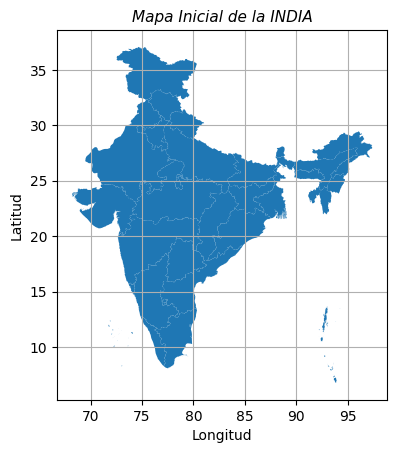

In [37]:
dfMAP.plot(missing_kwds={'color': 'lightgrey'})
plt.title("Mapa Inicial de la INDIA", fontsize=11, style='italic')
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.grid()
plt.show()

#### *-Se requiere superponer las etiquetas de los estados de la India en el MAPA*

In [38]:
import sys
!{sys.executable} -m pip install adjustText
!{sys.executable} -m pip install "mapclassify >= 2.4.0"

from adjustText import adjust_text #Para evitar que se supermonten las etiquetas

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


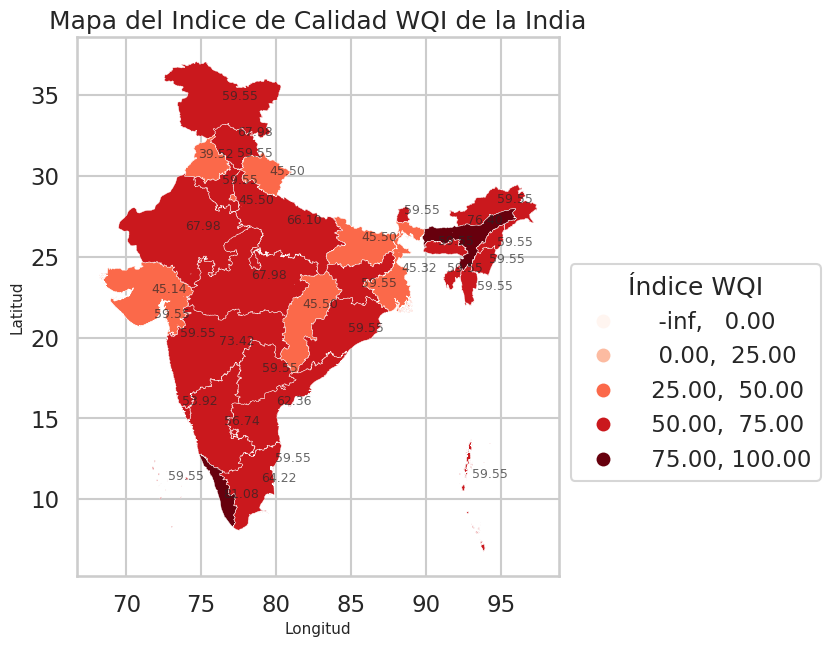

In [39]:
#Se verifica los valores NULOS; en caso de que existan se cambian por el promedio
#Se toma la ruta corta (la imputación de valores nulos puede ser mejor tratada)
dfMAP['WQI'] = dfMAP['WQI'].fillna(dfMAP['WQI'].median())

## Configuración de Estilos para ser usados en la impresión con seaborn
sns.set_context("talk") #puede ser cualquiera
sns.set_style("whitegrid") #Puede ser cualquiera de la biblioteca de estilos de seaborn

#Se ajusta el mapa 
fig, ax = plt.subplots(figsize = (12,7))
#dibujar el mapa
dfMAP.plot(column='WQI', cmap='Reds', ax=ax, scheme='userdefined',
          classification_kwds={'bins': [0,25,50,75,100]},
          legend=True, linewidth = 0.3)

##Ajustar la leyenda
leg = ax.get_legend()
leg.set_title('Índice WQI')
leg.set_bbox_to_anchor((1,0.6))

## Se agregan las etiquetas sin superposición (tener cuidado con el tamaño del PLOT)
textos = []
for _, row in dfMAP.iterrows():
    if not np.isnan(row['WQI']):
        centroide = row.geometry.centroid
        texto = ax.annotate(f"{row['WQI']:.2f}", xy=(centroide.x, centroide.y),
                           fontsize=9, alpha=0.7)
        textos.append(texto)
    
#Ajustar texto de etiquetas
adjust_text(textos, ax=ax, force_points=(0.2, 0.2))

### CARPINTERIA
ax.set_title("Mapa del Indice de Calidad WQI de la India")
ax.set_xlabel("Longitud", fontsize=11)
ax.set_ylabel("Latitud", fontsize=11)
plt.show()

### **Histograma de WQI por Estado**

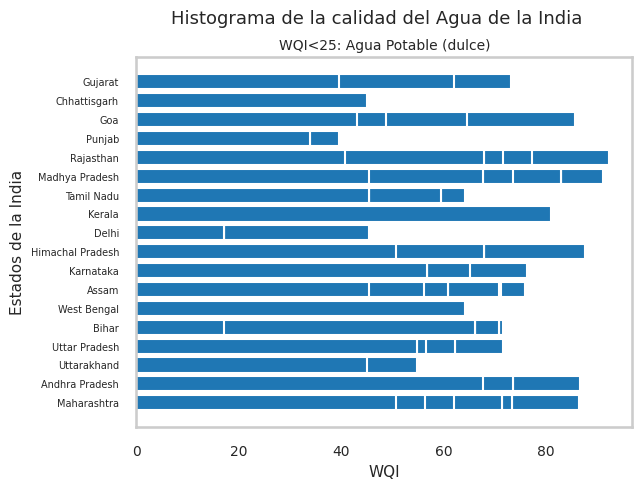

In [40]:
df06.createOrReplaceTempView("df06_sql")
#Se seleccionan los nombres de los estados
Estados = sparkS.sql("Select STATE from df06_sql")
Estados = Estados.rdd.map(lambda row: row.STATE).collect()

## Seleccionamos los valores de WQI
wqi = sparkS.sql("Select WQI from df06_sql")
wqi = wqi.rdd.map(lambda row: row.WQI).collect()

##Se grafica el histograma
plt.barh(Estados,wqi)
plt.suptitle("Histograma de la calidad del Agua de la India", fontsize=13)
plt.title("WQI<25: Agua Potable (dulce)", fontsize=10)
plt.xlabel("WQI", fontsize=11)
plt.ylabel("Estados de la India", fontsize=11)
plt.xticks(fontsize=10)
plt.yticks(fontsize=7)
plt.grid()
plt.show()

### **Creación de Modelo: Calidad de Agua en la India**

    - Se requiere predecir el parámetro WQI
    - Se crea un DF en pandas, un vector para manipular a través de numpy las columnas de calidad: "Rangos de Calidad" 
    - Se importa Scikit-Learn, para separar los datos (Entrenamiento y Prueba)
    - Se importa Keras Sequential Layers Dense
    - Se inicializa el modelo, y se añaden las capas
    - Se compila el modelo con el optimizador ADAM junto con la función de perdida de error cuadrático
    - Se realiza el experimento sobre los datos de entrenamiento
    - Se realiza la evaluación sobre los datos de prueba; para la selección del modelo.

In [41]:
df06.columns

['STATION CODE',
 'LOCATIONS',
 'STATE',
 'TEMP',
 'DO',
 'pH',
 'CONDUCTIVITY',
 'BOD',
 'NITRATE_N_NITRITE_N',
 'FECAL_COLIFORM',
 'qrPH',
 'qrDO',
 'qrCOND',
 'qrBOD',
 'qrNN',
 'qrFecal',
 'wpH',
 'wDO',
 'wCOND',
 'wBOD',
 'wNN',
 'wFecal',
 'WQI',
 'CALIDAD']

In [42]:
#- Se requiere predecir el parámetro WQI
#- Se crea un DF en pandas, un vector para manipular a través de numpy las columnas de calidad: "Rangos de Calidad"

dfcalidad = df06.select('qrPH','qrDO','qrCOND','qrBOD','qrNN','qrFecal')
dfPredecir = df06.select('WQI')

dfcalidad.show(5)
dfPredecir.show(5)

+----+----+------+-----+----+-------+
|qrPH|qrDO|qrCOND|qrBOD|qrNN|qrFecal|
+----+----+------+-----+----+-------+
| 100| 100|     0|   80| 100|    100|
| 100| 100|    40|   80| 100|     60|
| 100|  80|     0|   80| 100|     60|
| 100|  80|     0|   80| 100|     60|
| 100|  80|    40|   80| 100|     80|
+----+----+------+-----+----+-------+
only showing top 5 rows

+-----+
|  WQI|
+-----+
|73.42|
|71.54|
|56.56|
|56.56|
|71.54|
+-----+
only showing top 5 rows



In [43]:
#- Se crea un DF en pandas, un vector para manipular a través de numpy las columnas de calidad: "Rangos de Calidad" 
#- Se importa Scikit-Learn, para separar los datos (Entrenamiento: 80% y Prueba: 20%)

from sklearn.model_selection import train_test_split

dataTrain, dataTest, predTrain, predTest = train_test_split(dfcalidad.toPandas(), dfPredecir.toPandas(), test_size=0.2, random_state=1)

In [44]:
print(f"Cantidad de datos totales: {df06.count(), len(df06.columns)}")
print(f"Cantidad de datos Entrenamiento: {dataTrain.shape}")
print(f"Cantidad de datos Prueba: {dataTest.shape}")
print(f"Cantidad de datos Predicción del Entrenamiento: {predTrain.shape}")
print(f"Cantidad de datos Predicción de Prueba: {predTest.shape}")

Cantidad de datos totales: (534, 24)
Cantidad de datos Entrenamiento: (427, 6)
Cantidad de datos Prueba: (107, 6)
Cantidad de datos Predicción del Entrenamiento: (427, 1)
Cantidad de datos Predicción de Prueba: (107, 1)


In [45]:
## Se importa la instancia TensorFlow
import keras
from keras.models import Sequential
from keras.layers import Dense

2026-04-26 11:13:31.833533: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-26 11:13:31.907252: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-26 11:13:33.976062: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [46]:
#Se ajustan las variables: El ajuste es de forma estandar. Se requiere un estudio profundo sobre el
# ajuste de los parámetros, para que sea el modelo mucho más eficiente. El estudio a continuación
# es un a guia para abordar modelos de Tensores en Predicción de calidad de agua, como guía metodológica
# académica.

epocas = 200
lote = 81
#Se inicializa el modelo con las capas
modelo01 = Sequential()
modelo01.add(Dense(350,input_dim=6,activation='relu'))
modelo01.add(Dense(350,activation='relu'))
modelo01.add(Dense(350,activation='relu'))
modelo01.add(Dense(1,activation='linear'))

/home/estudiante/.local/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-04-26 11:13:34.255736: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [47]:
#Para optimizar el modelo se usa el optimizador ADAM
#La compilación se ajusta a la pérdida del error cuadrático
keras.optimizers.Adam(learning_rate=0.001, beta_1=0.9, beta_2=0.999, amsgrad=False)
modelo01.compile(loss='mean_squared_error', optimizer='Adam', metrics=['mse'])

In [48]:
modelo01.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 350)            │         2,450 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 350)            │       122,850 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 350)            │       122,850 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           351 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 248,501 (970.71 KB)

 Trainable params: 248,501 (970.71 KB)

 Non-trainable params: 0 (0.00 B)

In [49]:
ejecutarK = modelo01.fit(dataTrain, predTrain, epochs=epocas, batch_size=lote)

Epoch 1/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 998.8951 - mse: 998.8950
Epoch 2/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 129.0757 - mse: 129.0757
Epoch 3/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 58.1820 - mse: 58.1820
Epoch 4/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 26.3409 - mse: 26.3409
Epoch 5/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 8.7294 - mse: 8.7294
Epoch 6/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 4.8816 - mse: 4.8816
Epoch 7/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 2.3372 - mse: 2.3372
Epoch 8/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 1.5688 - mse: 1.5688
Epoch 9/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 1.0337 - mse: 1.0337
Epoch 10/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.5578 - mse: 0.5578
Epoch 11/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.4694 - mse: 0.4694
Epoch 12/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.3066 - mse: 0.3066
Epoch 13/200
6/6 ━━━━━━━━━━━━━━━━━━━━

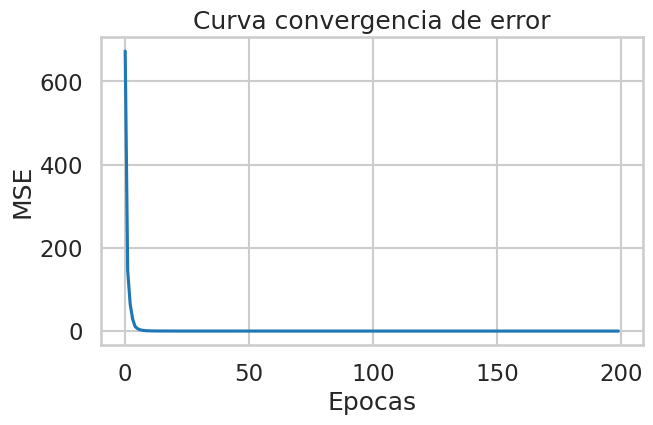

In [50]:
plt.figure(figsize=(7,4))
plt.plot(ejecutarK.history['loss'])
plt.title("Curva convergencia de error")
plt.xlabel("Epocas")
plt.ylabel("MSE")
plt.show()

In [51]:
### Se requiere predecir sobre los datos del entrenamiento
predModelo01_Train = modelo01.predict(dataTrain)

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


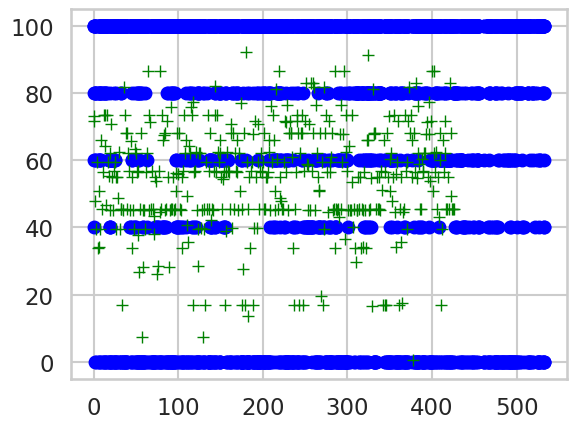

In [52]:
### Se pinta la predicción
plt.plot(dataTrain, 'bo', predModelo01_Train, 'g+')
plt.show()